<div style="
    direction: rtl;
    text-align: right;
    font-family: 'Vazirmatn', 'IRANSans', sans-serif;
    max-width: 760px;
    margin: 14px auto;
    padding: 16px 18px 16px 14px;
    border-radius: 18px;
    background: #ffffff;
    border: 1px solid #e5e7eb;
    border-right: 6px solid #2563eb;
    box-shadow: 0 6px 18px rgba(0, 0, 0, 0.045);
">
  <div style="margin-left: 18px;">
    <div style="
        display: inline-block;
        font-size: 11px;
        font-weight: 700;
        color: #1d4ed8;
        background: #eff6ff;
        padding: 4px 11px;
        border-radius: 999px;
        margin-bottom: 10px;
    ">
      دوره مبانی هوش مصنوعی
    </div>
    <div style="
        font-size: 24px;
        font-weight: 900;
        color: #111827;
        line-height: 1.4;
        margin-bottom: 6px;
    ">
      یادگیری ماشین بدون نظارت | Unsupervised Machine Learning
    </div>
    <div style="
        width: 56px;
        height: 3px;
        background: linear-gradient(90deg, #2563eb, #60a5fa);
        border-radius: 999px;
        margin-bottom: 10px;
    "></div>
    <div style="
        font-size: 15px;
        font-weight: 700;
        color: #374151;
        margin-bottom: 4px;
    ">
      دبیرستان دوره اول علامه حلی ۵ تهران
    </div>
    <div style="
        font-size: 14px;
        color: #4b5563;
        line-height: 1.7;
        margin-bottom: 10px;
    ">
    <span style="font-weight: 700; color: #111827;">پارسا صدری</span> و <span style="font-weight: 700; color: #111827;">علیرضا سپهری</span>
    </div>
    <div style="
        display: inline-block;
        font-size: 12px;
        color: #1e40af;
        background: #f0f9ff;
        padding: 4px 10px;
        border-radius: 999px;
        border: 1px solid #bae6fd;
    ">
      تابستان ۱۴۰۵
    </div>
  </div>
</div>


در این بخش، مدل **جواب درست** را از قبل نمی‌داند.  
مدل فقط داده‌ها را می‌بیند و سعی می‌کند خودش **خوشه ها (Cluster)** را پیدا کند.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler

## 1) بارگذاری داده

برای خوشه‌بندی از دیتاست Iris استفاده می‌کنیم.  
در اینجا فقط از **ویژگی‌ها** استفاده می‌کنیم، نه از برچسب‌ها.

In [3]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)

print("تعداد داده‌ها:", X.shape[0])
print("تعداد ویژگی‌ها:", X.shape[1])

X.head()

تعداد داده‌ها: 150
تعداد ویژگی‌ها: 4


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 2) نمایش اولیه داده

برای اینکه خوشه‌ها را بهتر ببینیم، فقط دو ویژگی اول را روی نمودار رسم می‌کنیم.

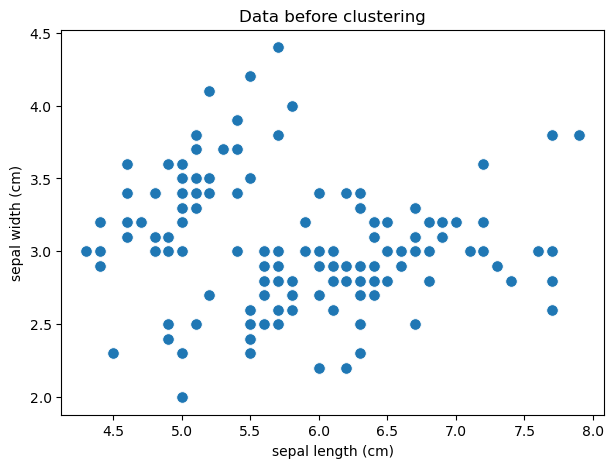

In [5]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=X.iloc[:,0], y=X.iloc[:,1], s=70)
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title("Data before clustering")
plt.show()

## 3) استانداردسازی داده

چون مقیاس ویژگی‌ها ممکن است متفاوت باشد، داده‌ها را استاندارد می‌کنیم.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 4) مدل اول: KMeans

در KMeans، ما تعداد گروه‌ها را خودمان مشخص می‌کنیم.  
اینجا می‌گوییم داده‌ها در **3 گروه** تقسیم شوند.

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


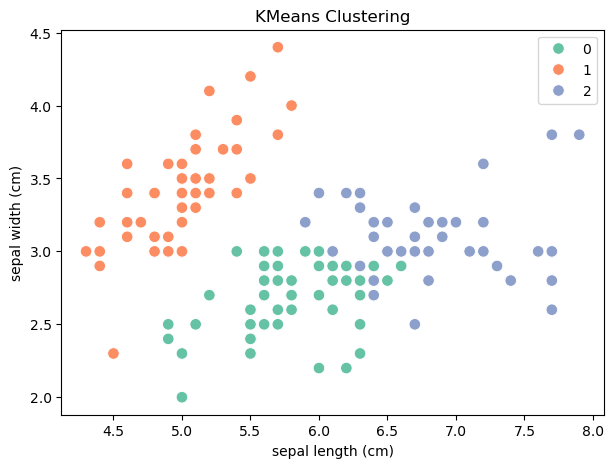

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(7,5))
sns.scatterplot(x=X.iloc[:,0], y=X.iloc[:,1], hue=kmeans_labels, palette="Set2", s=70)
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title("KMeans Clustering")
plt.show()

## 5) مدل دوم: DBSCAN

این مدل بر اساس تراکم کار می‌کند.  
اگر نقطه‌ای به هیچ گروهی شبیه نباشد، ممکن است آن را **نویز** در نظر بگیرد.

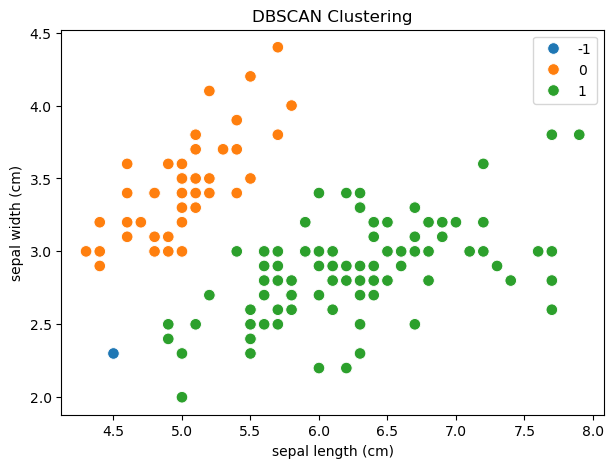

In [8]:
dbscan = DBSCAN(eps=1.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(7,5))
sns.scatterplot(x=X.iloc[:,0], y=X.iloc[:,1], hue=dbscan_labels, palette="tab10", s=70)
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title("DBSCAN Clustering")
plt.show()

## 6) جمع‌بندی

- در **Unsupervised Learning** مدل جواب درست را از قبل ندارد.
- مدل سعی می‌کند داده‌های شبیه را در یک گروه قرار دهد.
- امروز 2 روش خوشه‌بندی دیدیم:
  - KMeans
  - DBSCAN

In [1]:
from IPython.display import HTML

HTML("""
<style>
.jp-RenderedMarkdown, 
.rendered_html, 
.jp-MarkdownOutput {
    direction: rtl !important;
    text-align: right !important;
    font-family: "Vazirmatn", "Vazir", sans-serif !important;
    line-height: 1.8 !important;
}
.jp-RenderedMarkdown p, 
.jp-RenderedMarkdown li, 
.jp-RenderedMarkdown h1, 
.jp-RenderedMarkdown h2, 
.jp-RenderedMarkdown h3, 
.jp-RenderedMarkdown h4, 
.jp-RenderedMarkdown div,
.rendered_html p, 
.rendered_html li, 
.rendered_html h1, 
.rendered_html h2, 
.rendered_html h3 {
    direction: rtl !important;
    text-align: right !important;
    font-family: "Vazirmatn", "Vazir", sans-serif !important;
}
.jp-RenderedMarkdown ul, 
.jp-RenderedMarkdown ol,
.rendered_html ul, 
.rendered_html ol {
    padding-right: 2em !important;
    padding-left: 0 !important;
}
</style>
""")